<h3 style='color:#2e6c80;margin-bottom:8px'>FYS-3033: Mandatory Assignment — Problem 1</h3>
<div style='font-size:14px;line-height:1.4;margin-bottom:10px'>Candidate ID: <i>7429216</i><br>Assignment: <i>Classifying handwritten digit data using both image and audio modalities</i></div>

<h3 style='color:#2e6c80;margin-bottom:8px'>Problem 1a: Image-based Unimodal Model</h3>
<div style='font-size:14px;line-height:1.4;margin-bottom:10px'>Design a unimodal model using only the image data.</div>
<ul style='margin-top:0px;margin-bottom:10px;padding-left:20px;font-size:13px;'>
<li>Build and train the model.</li>
<li>Plot training loss and test accuracy.</li>
<li>Display 5 training and 5 test set image samples.</li>
<li>Evaluate and interpret the model’s performance.</li>
</ul>

Using device: mps
Train Images: torch.Size([17560, 1, 28, 28]), Labels: torch.Size([17560])
Test  Images: torch.Size([5859, 1, 28, 28]),  Labels: torch.Size([5859])
Train Images Resize 1-channel: torch.Size([17560, 1, 224, 224]), Labels: torch.Size([17560])
Test  Images Resize 1-channel: torch.Size([5859, 1, 224, 224]),  Labels: torch.Size([5859])
Train Images Resize 3-channel: torch.Size([17560, 3, 224, 224]), Labels: torch.Size([17560])
Test  Images Resize 3-channel: torch.Size([5859, 3, 224, 224]),  Labels: torch.Size([5859])


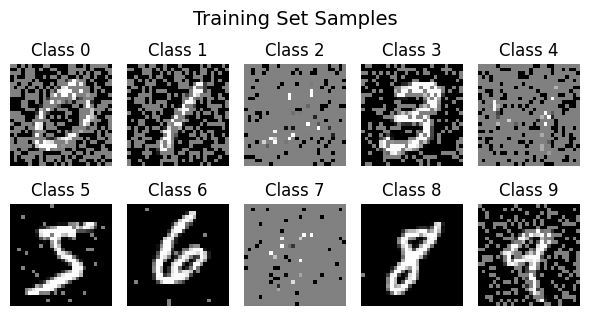

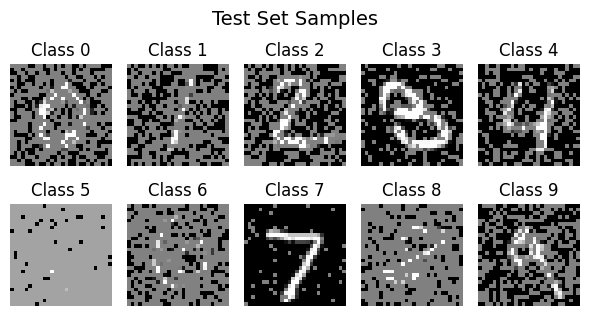

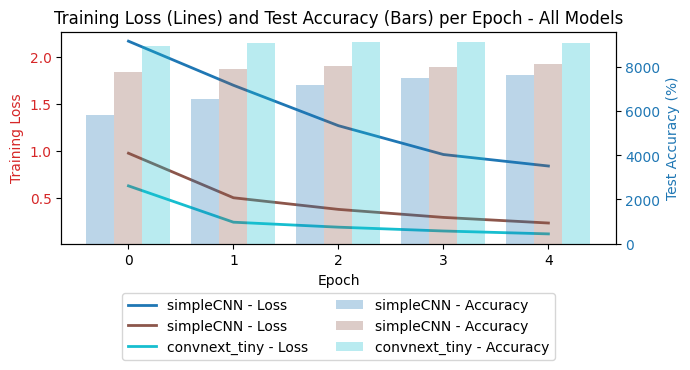


Visual Results:
| Data Type              | Model         | Train Accuracy   | Test Accuracy   | Training Time   |
|------------------------|---------------|------------------|-----------------|-----------------|
| original               | simpleCNN     | 80.17%           | 76.45%          | 13.32s          |
| interpolated_1-channel | simpleCNN     | 95.21%           | 81.14%          | 632.32s         |
| interpolated_3-channel | convnext_tiny | 96.81%           | 90.77%          | 1363.50s        |


In [ ]:
#!/usr/bin/env python3
# ------------------- Imports -------------------
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import timm
import matplotlib.pyplot as plt
from tqdm import tqdm
from tabulate import tabulate
import numpy as np
# ------------------- Constants & Hyperparameters -------------------
DATA_DIR = "data"
BATCH_SIZE = 64
LEARNING_RATE = 1e-5
NUM_EPOCHS = 5
NUM_CLASSES = 10
MODELS = [
    "simpleCNN",
    "convnext_tiny"
]

# ------------------- Device Setup -------------------
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# ------------------- Data Handling -------------------
def resize(x, size=224):
    """Resize images to the specified size."""
    return F.interpolate(x, size=(size, size), mode='bilinear', align_corners=False)

def repeat(x): # for pre-trained models
    """Repeat the input tensor to match the expected input shape for pre-trained models."""
    return x.repeat(1, 3, 1, 1)

def load_visual_data(data_dir):
    train_images = torch.load(f"{data_dir}/training_images.pth")
    train_labels = torch.load(f"{data_dir}/training_images_labels.pth")
    test_images = torch.load(f"{data_dir}/test_images.pth")
    test_labels = torch.load(f"{data_dir}/test_images_labels.pth")
    return train_images, train_labels, test_images, test_labels

def create_dataloaders(train_data, test_data, batch_size):
    train_loader = DataLoader(TensorDataset(*train_data), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(*test_data), batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

# ------------------- Plotting Functions -------------------
def plot_visual_samples(images, labels, classes=10, title=""):
    """Display the first image of each class in a 2x5 grid."""
    fig, axes = plt.subplots(2, 5, figsize=(6, 3.5))
    fig.suptitle(title, fontsize=14, y=0.95)
    shown = set()
    idx = 0
    for i, label in enumerate(labels):
        label = label.item()
        if label not in shown:
            img = images[i].squeeze().numpy()
            ax = axes[idx // 5][idx % 5]
            ax.imshow(img, cmap='gray')
            ax.set_title(f"Class {label}")
            ax.axis('off')
            shown.add(label)
            idx += 1
        if len(shown) == classes:
            break
    plt.tight_layout()
    plt.show()

def plot_combined_loss_and_accuracy(models_results):
    num_epochs = len(models_results[0]['train_loss'])
    num_models = len(models_results)
    epoch_indices = np.arange(num_epochs)
    fig, ax1 = plt.subplots(figsize=(7, 4))
    colors = plt.cm.tab10(np.linspace(0, 1, num_models))  # distinct colors
    bar_width = 0.8 / num_models  # total bar width per epoch = 0.8
    offset = - (num_models - 1) / 2 * bar_width  # center bars
    # Plot bars for test accuracy
    ax2 = ax1.twinx()
    for i, model in enumerate(models_results):
        acc = np.array(model['test_accuracy']) * 100  # convert to %
        bar_positions = epoch_indices + (i * bar_width) + offset
        ax2.bar(bar_positions, acc, width=bar_width, label=f"{model['name']} - Accuracy", alpha=0.3, color=colors[i])
    # Plot lines for training loss
    for i, model in enumerate(models_results):
        ax1.plot(epoch_indices, model['train_loss'], label=f"{model['name']} - Loss", color=colors[i], linewidth=2)

    # Axes labels and title
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Training Loss", color='tab:red')
    ax2.set_ylabel("Test Accuracy (%)", color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=10)

    plt.title("Training Loss (Lines) and Test Accuracy (Bars) per Epoch - All Models", fontsize=12)
    plt.tight_layout()
    plt.show()

# ------------------- Models ---------------------
class preTrainedCNNModel(nn.Module):
    """Pre-trained CNN model using timm library."""
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

class simpleCNN(nn.Module):
    """Simple CNN Encoder from the 1st practice in the course """
    def __init__(self, num_classes=10, prj_dim=4096):
        super(simpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.proj  = nn.Sequential(nn.LazyLinear(prj_dim), nn.ReLU())
        self.fc1   = nn.LazyLinear(num_classes)  # Use LazyLinear to define later based on input size

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Input shape:    [batch_size, 1, W, H]
        Output shape:   [batch_size, 64 * W/4 * H/4]
        Example of Visual:          [64, 1, 28, 28]  -> [64, 64 * 7 * 7]  = [64, 3136]
        Example of Melspectrogram:  [64, 1, 32, 201] -> [64, 64 * 8 * 50] = [64, 25600]
        """
        x = F.relu(self.conv1(x))   # [batch_size, 32, W, H]
        x = F.max_pool2d(x, 2)      # [batch_size, 32, W/2, H/2]
        x = F.relu(self.conv2(x))   # [batch_size, 64, W/2, H/2]
        x = F.max_pool2d(x, 2)      # [batch_size, 64, W/4, H/4]
        x = x.view(x.size(0), -1)   # Flatten: [batch_size, 64 * W/4 * H/4] 
        x = self.proj(x)            # Project: [batch_size, prj_dim]
        x = self.fc1(x)
        return x

# ------------------- Training and Evaluation -------------------
def train_and_evaluate(model, train_loader, test_loader, infor, num_epochs, learning_rate):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    test_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        progress_bar = tqdm(train_loader, leave=False, desc=f"{infor['model_name']}-{infor['data_type']} Epoch {epoch+1}")
        for x, y in progress_bar:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            avg_loss = total_loss / (progress_bar.n + 1)
            progress_bar.set_postfix(loss=f"{avg_loss:.4f}")
                
        train_losses.append(avg_loss)
        test_accuracy = evaluate(model, test_loader)
        test_accuracies.append(test_accuracy)
    train_accuracy = evaluate(model, train_loader)
    return train_accuracy, train_losses, test_accuracies

def evaluate(model, test_loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    accuracy = 100 * correct / total
    return accuracy

# ------------------- Experiment Runner -------------------
def run_experiments():
    train_images_data, train_images_labels, test_images_data, test_images_labels = load_visual_data(DATA_DIR)
    train_images_1channel, test_images_1channel = resize(train_images_data), resize(test_images_data)
    train_images_3channel, test_images_3channel = repeat(train_images_1channel), repeat(test_images_1channel)
    train_loader_origin, test_loader_origin     = create_dataloaders((train_images_data, train_images_labels), (test_images_data, test_images_labels), BATCH_SIZE)
    train_loader_1channel, test_loader_1channel = create_dataloaders((train_images_1channel, train_images_labels), (test_images_1channel, test_images_labels), BATCH_SIZE)
    train_loader_3channel, test_loader_3channel = create_dataloaders((train_images_3channel, train_images_labels), (test_images_3channel, test_images_labels), BATCH_SIZE)
    print(f"Train Images: {train_images_data.shape}, Labels: {train_images_labels.shape}")
    print(f"Test  Images: {test_images_data.shape},  Labels: {test_images_labels.shape}")
    print(f"Train Images Resize 1-channel: {train_images_1channel.shape}, Labels: {train_images_labels.shape}")
    print(f"Test  Images Resize 1-channel: {test_images_1channel.shape},  Labels: {test_images_labels.shape}")
    print(f"Train Images Resize 3-channel: {train_images_3channel.shape}, Labels: {train_images_labels.shape}")
    print(f"Test  Images Resize 3-channel: {test_images_3channel.shape},  Labels: {test_images_labels.shape}")
    plot_visual_samples(train_images_data, train_images_labels, title="Training Set Samples")
    plot_visual_samples(test_images_data, test_images_labels, title="Test Set Samples")
    results = []
    model_name = "simpleCNN"
    infor = { 'model_name': model_name, 'data_type': 'original'}
    model = simpleCNN(NUM_CLASSES) # Simple CNN model for original data
    train_loader, test_loader = train_loader_origin, test_loader_origin
    start_time   = time.time()
    train_accuracy, train_losses, test_accuracies = train_and_evaluate(model, train_loader, test_loader, infor, NUM_EPOCHS, LEARNING_RATE)
    elapsed_time = time.time() - start_time
    results.append({
        'name': model_name,
        'data_type': 'original',
        'train_loss': train_losses,
        'test_accuracy': test_accuracies,
        'train_acc_final': f"{train_accuracy:.2f}%",
        'test_acc_final': f"{test_accuracies[-1]:.2f}%",
        'training_time': f"{elapsed_time:.2f}s"
    })
    
    for model_name in MODELS:
        model        = simpleCNN(NUM_CLASSES)   if model_name == "simpleCNN" else preTrainedCNNModel(model_name, NUM_CLASSES)
        train_loader = train_loader_1channel    if model_name == "simpleCNN" else train_loader_3channel
        test_loader  = test_loader_1channel     if model_name == "simpleCNN" else test_loader_3channel
        data_type    = 'interpolated_1-channel' if model_name == "simpleCNN" else 'interpolated_3-channel'
        start_time   = time.time()
        infor = { 'model_name': model_name, 'data_type': data_type}
        train_accuracy, train_losses, test_accuracies = train_and_evaluate(model, train_loader, test_loader, infor, NUM_EPOCHS, LEARNING_RATE)
        elapsed_time = time.time() - start_time
        results.append({
            'name': model_name,
            'data_type': data_type,
            'train_loss': train_losses,
            'test_accuracy': test_accuracies,
            'train_acc_final': f"{train_accuracy:.2f}%",
            'test_acc_final': f"{test_accuracies[-1]:.2f}%",
            'training_time': f"{elapsed_time:.2f}s"
        })
    return results
    
# ------------------- Entry Point -------------------
if __name__ == "__main__":
    visual_results = run_experiments()

    plot_combined_loss_and_accuracy(visual_results)

    print("\nVisual Results:")
    visual_summary_table = [
        [r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']]  for r in visual_results
    ]
    print(tabulate(visual_summary_table, headers=["Data Type", "Model", "Train Accuracy", "Test Accuracy", "Training Time"], tablefmt="github"))


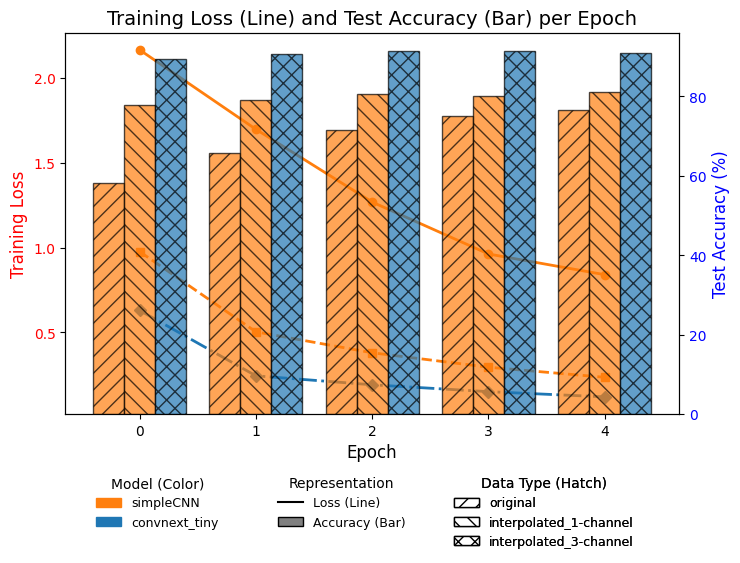

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

def plot_combined_loss_and_accuracy(models_results):
    num_epochs = len(models_results[0]['train_loss'])
    num_models = len(models_results)
    epoch_indices = np.arange(num_epochs)

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()

    # Style setup
    color_cycle = plt.cm.tab10.colors
    marker_cycle = ['o', 's', 'D', '^', 'v', '<', '>', 'P', '*', 'X']
    line_style_cycle = ['-', '--', '-.', ':']
    hatch_base = ['/', '\\', 'x', '-', '+', '.', '*', 'O']
    hatch_cycle = itertools.cycle([h*2 for h in hatch_base])  # Dense hatch

    markers = itertools.cycle(marker_cycle)
    line_styles = itertools.cycle(line_style_cycle)

    # Assign unique color per model name
    unique_model_names = list({model['name'] for model in models_results})
    color_map = {name: color_cycle[i % len(color_cycle)] for i, name in enumerate(unique_model_names)}

    # Bar width
    bar_width = 0.8 / num_models
    offset = - (num_models - 1) / 2 * bar_width

    # Legend handles
    model_handles = {}
    hatch_handles = {}
    line_style_handle = Line2D([0], [0], color='black', linestyle='-', label='Loss (Line)')
    bar_style_handle = Patch(facecolor='gray', edgecolor='black', label='Accuracy (Bar)')

    # First: bars
    for i, model in enumerate(models_results):
        model_name = model['name']
        data_type = model.get('data_type', f"Data {i+1}")
        color = color_map[model_name]
        hatch = next(hatch_cycle)
        acc = np.array(model['test_accuracy'])
        bar_positions = epoch_indices + (i * bar_width) + offset

        ax2.bar(bar_positions, acc, width=bar_width, color=color,
                alpha=0.7, edgecolor='black', hatch=hatch, zorder=1) # zorder -> in the back

        # Store legend handles
        if model_name not in model_handles:
            model_handles[model_name] = Patch(color=color, label=model_name)
        if data_type not in hatch_handles:
            hatch_handles[data_type] = Patch(facecolor='white', edgecolor='black', hatch=hatch, label=data_type)

    # Then: lines on top
    markers = itertools.cycle(marker_cycle)
    line_styles = itertools.cycle(line_style_cycle)
    for i, model in enumerate(models_results):
        model_name = model['name']
        color = color_map[model_name]
        marker = next(markers)
        line_style = next(line_styles)
        ax1.plot(epoch_indices, model['train_loss'],
                 linestyle=line_style, marker=marker,
                 color=color, linewidth=2, markersize=6, zorder=3) #zorder -> in the front

    # Labels and ticks
    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("Training Loss", color='red', fontsize=12)
    ax2.set_ylabel("Test Accuracy (%)", color='blue', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='red')
    ax2.tick_params(axis='y', labelcolor='blue')
    ax1.set_xticks(epoch_indices)
    plt.title("Training Loss (Line) and Test Accuracy (Bar) per Epoch", fontsize=14)

    model_legend = ax1.legend(
        handles=list(model_handles.values()),
        title='Model (Color)',
        loc='lower center',
        bbox_to_anchor=(0.15, -0.33),
        fontsize=9,
        title_fontsize=10,
        frameon=False
    )
    ax1.add_artist(model_legend)

    representation_legend = ax1.legend(
        handles=[line_style_handle, bar_style_handle],
        title='Representation',
        loc='lower center',
        bbox_to_anchor=(0.45, -0.33),
        fontsize=9,
        title_fontsize=10,
        frameon=False
    )
    ax1.add_artist(representation_legend)

    hatch_legend = ax1.legend(
        handles=list(hatch_handles.values()),
        title='Data Type (Hatch)',
        loc='lower center',
        bbox_to_anchor=(0.78, -0.38),
        fontsize=9,
        title_fontsize=10,
        frameon=False
    )
    ax1.add_artist(hatch_legend)


    # Apply all
    plt.tight_layout(rect=[0, 0.35, 0.75, 0.75])
    plt.subplots_adjust(bottom=0.05)
    plt.show()

plot_combined_loss_and_accuracy(visual_results)

In [67]:
visual_results[0]['train_loss']


[2.1666275898035425,
 1.6982318686914968,
 1.2690896274465504,
 0.9629816661461693,
 0.8408687914732291]

<h3 style='color:#2e6c80;margin-bottom:8px'>Problem 1b: Audio-based Unimodal Model</h3>
<div style='font-size:14px;line-height:1.4;margin-bottom:10px'>Repeat 1a using only the audio data.</div>
<ul style='margin-top:0px;margin-bottom:10px;padding-left:20px;font-size:13px;'>
<li>Plot training loss and test accuracy.</li>
<li>Display 5 audio samples from training and test sets.</li>
<li>Evaluate and interpret the model’s performance.</li>
</ul>

Using device: mps
Train Audios: torch.Size([17560, 1, 32, 201]), Labels: torch.Size([17560])
Test  Audios: torch.Size([5859, 1, 32, 201]),  Labels: torch.Size([5859])
Train Audios Resize 1-channel: torch.Size([17560, 1, 224, 224]), Labels: torch.Size([17560])
Test  Audios Resize 1-channel: torch.Size([5859, 1, 224, 224]),  Labels: torch.Size([5859])
Train Audios Resize 3-channel: torch.Size([17560, 3, 224, 224]), Labels: torch.Size([17560])
Test  Audios Resize 3-channel: torch.Size([5859, 3, 224, 224]),  Labels: torch.Size([5859])


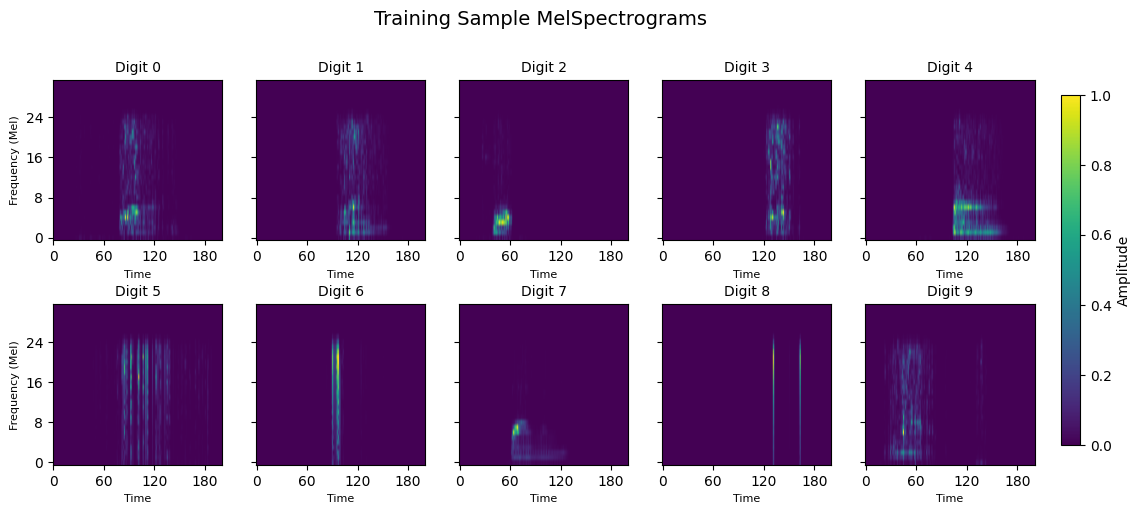

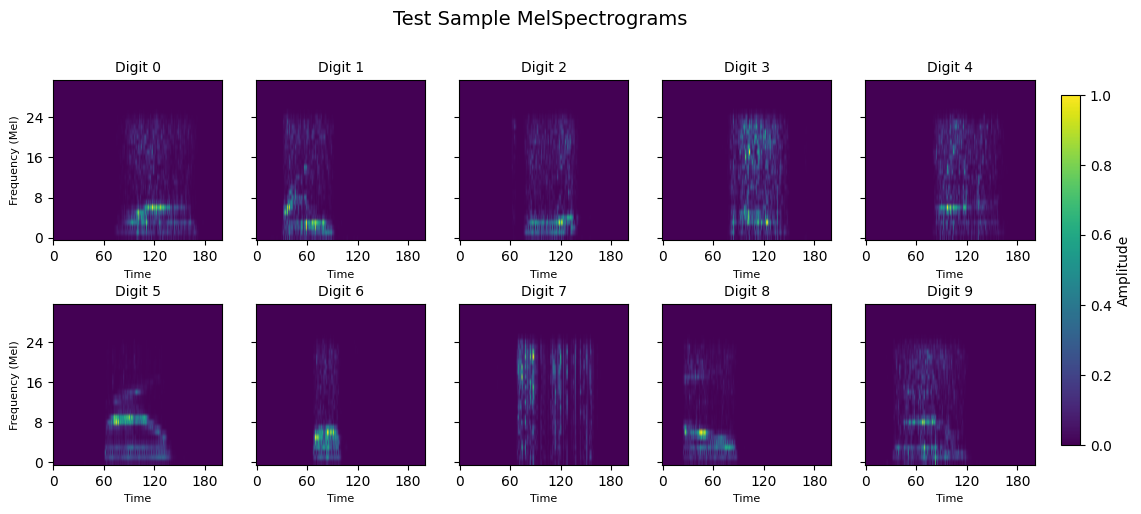

ValueError: too many values to unpack (expected 2)

In [ ]:
#!/usr/bin/env python3
# ------------------- Imports -------------------
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio.transforms as T
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from tqdm import tqdm
from tabulate import tabulate
import timm

# ------------------- Configuration -------------------
DATA_DIR = "data"
BATCH_SIZE = 64
NUM_EPOCHS = 5
LEARNING_RATE = 1e-5
NUM_CLASSES = 10
ORIG_SAMPLE_RATE = 8000
TARGET_SAMPLE_RATE = 16000
MODELS = [
    "simpleCNN",
    "convnext_tiny"
]
DATA_TYPES = {
    "Original Data": "original",
    "Interpolated 1-Channel": "interpolated_1-channel",
    #"Interpolated 3-Channel": "interpolated_3-channel" #Not used in this practice
}
# ------------------- Device -------------------
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print(f"Using device: {device}")

# -------------------  Data Handling -------------------
def resize(x, size=224):
    """Resize images to the specified size."""
    return F.interpolate(x, size=(size, size), mode='bilinear', align_corners=False)

def repeat(x): # for pre-trained models
    """Repeat the input tensor to match the expected input shape for pre-trained models."""
    return x.repeat(1, 3, 1, 1)
def transform_mel(audio_data):
    mel_transform = T.MelSpectrogram(
        sample_rate=TARGET_SAMPLE_RATE,
        n_fft=256,
        hop_length=80,
        n_mels=32,
        normalized=True
    )
    mel_spectrograms = torch.stack([mel_transform(wf) for wf in audio_data])
    return mel_spectrograms

def resample_audio(train_audio_data, test_audio_data):
    resampler = T.Resample(orig_freq=ORIG_SAMPLE_RATE, new_freq=TARGET_SAMPLE_RATE)
    train_audio_resampled = torch.stack([resampler(wf.float()) for wf in train_audio_data])
    test_audio_resampled = torch.stack([resampler(wf.float()) for wf in test_audio_data])
    return train_audio_resampled, test_audio_resampled

def load_audio_data(data_dir): # from 8000 to 16000 Hz
    train_audio_data   = torch.load(f"{data_dir}/training_audio.pth")
    train_audio_labels = torch.load(f"{data_dir}/training_audio_labels.pth")
    test_audio_data    = torch.load(f"{data_dir}/test_audio.pth")
    test_audio_labels  = torch.load(f"{data_dir}/test_audio_labels.pth")
    train_audio_data, test_audio_data = resample_audio(train_audio_data, test_audio_data)
    train_audio_mels, test_audio_mels = transform_mel(train_audio_data), transform_mel(test_audio_data)
    return train_audio_mels, train_audio_labels, test_audio_mels, test_audio_labels

def create_dataloaders(train_data, test_data, batch_size):
    train_loader = DataLoader(TensorDataset(*train_data), batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(TensorDataset(*test_data), batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

# ------------------- Plotting Functions -------------------
def plot_spectrogram_samples(mel_spectrograms, labels, classes=10, title=""):
    """Plot one MelSpectrogram per class in a 2x5 grid, with one frequency label per row, time labels, and enhanced color intensity."""
    fig, axes = plt.subplots(2, 5, figsize=(13, 5))
    fig.suptitle(title, fontsize=14, y=1.02)
    shown = set()
    idx = 0
    im = None  # for colorbar
    for i in range(len(labels)):
        label = labels[i].item()
        if label not in shown:
            spec = mel_spectrograms[i].squeeze().numpy()
            # Normalize spectrogram to [0, 1] for better color contrast
            spec = (spec - np.min(spec)) / (np.max(spec) - np.min(spec) + 1e-6)
            row = idx // 5
            col = idx % 5
            ax = axes[row][col]
            im = ax.imshow(spec, origin="lower", aspect="auto", cmap="viridis", vmin=0, vmax=1)
            ax.set_title(f"Digit {label}", fontsize=10)
            # Frequency label only for leftmost subplot in each row
            if col == 0:
                ax.set_ylabel("Frequency (Mel)", fontsize=8)
            else:
                ax.set_yticklabels([])
                ax.set_ylabel("")
            # Time label for all
            ax.set_xlabel("Time", fontsize=8)
            ax.xaxis.set_major_locator(plt.MaxNLocator(4))
            ax.yaxis.set_major_locator(plt.MaxNLocator(4))
            shown.add(label)
            idx += 1
        if len(shown) == classes:
            break
    # Adjust layout for colorbar
    plt.subplots_adjust(right=0.88, hspace=0.4, wspace=0.2)
    cbar_ax = fig.add_axes([0.9, 0.15, 0.015, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label("Amplitude", fontsize=10)
    plt.show()
    
def plot_combined_loss_and_accuracy(models_results):
    num_epochs = len(models_results[0]['train_loss'])
    num_models = len(models_results)
    epoch_indices = np.arange(num_epochs)

    fig, ax1 = plt.subplots(figsize=(7, 4))

    colors = plt.cm.tab10(np.linspace(0, 1, num_models))  # distinct colors

    bar_width = 0.8 / num_models  # total bar width per epoch = 0.8
    offset = - (num_models - 1) / 2 * bar_width  # center bars

    # Plot bars for test accuracy
    ax2 = ax1.twinx()
    for i, model in enumerate(models_results):
        acc = np.array(model['test_accuracy']) * 100  # convert to %
        bar_positions = epoch_indices + (i * bar_width) + offset
        ax2.bar(bar_positions, acc, width=bar_width, label=f"{model['name']} - Accuracy", alpha=0.3, color=colors[i])

    # Plot lines for training loss
    for i, model in enumerate(models_results):
        ax1.plot(epoch_indices, model['train_loss'], label=f"{model['name']} - Loss", color=colors[i], linewidth=2)

    # Axes labels and title
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Training Loss", color='tab:red')
    ax2.set_ylabel("Test Accuracy (%)", color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=10)

    plt.title("Training Loss (Lines) and Test Accuracy (Bars) per Epoch - All Models", fontsize=12)
    plt.tight_layout()
    plt.show()
# ------------------- Models ----------------------
class preTrainedCNNModel(nn.Module):
    """Pre-trained CNN model using timm library."""
    def __init__(self, model_name, num_classes=10):
        super().__init__()
        self.model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

    def forward(self, x):
        return self.model(x)
    
class simpleCNN(nn.Module):
    """Simple CNN Encoder from the 1st practice in the course """
    def __init__(self, num_classes=10, prj_dim=4096):
        super(simpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.proj  = nn.Sequential(nn.LazyLinear(prj_dim), nn.ReLU())
        self.fc1 = nn.LazyLinear(num_classes)  # Use LazyLinear to define later based on input size

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Input shape:    [batch_size, 1, W, H]
        Output shape:   [batch_size, 64 * W/4 * H/4]
        Example of Visual:          [64, 1, 28, 28]  -> [64, 64 * 7 * 7]  = [64, 3136]
        Example of Melspectrogram:  [64, 1, 32, 201] -> [64, 64 * 8 * 50] = [64, 25600]
        """
        x = F.relu(self.conv1(x))   # [batch_size, 32, W, H]
        x = F.max_pool2d(x, 2)      # [batch_size, 32, W/2, H/2]
        x = F.relu(self.conv2(x))   # [batch_size, 64, W/2, H/2]
        x = F.max_pool2d(x, 2)      # [batch_size, 64, W/4, H/4]
        x = x.view(x.size(0), -1)   # Flatten: [batch_size, 64 * W/4 * H/4]  
        x = self.proj(x)            # Projecting: [batch_size, prj_dim]
        x = self.fc1(x)
        return x
# ------------------- Training and Evaluation -------------------
def train_and_evaluate(model, train_loader, test_loader, infor, num_epochs, learning_rate):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    train_losses = []
    test_accuracies = []
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        progress_bar = tqdm(train_loader, leave=False, desc=f"{infor['model_name']}-{infor['data_type']} Epoch {epoch+1}")
        for x, y in progress_bar:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            avg_loss = total_loss / (progress_bar.n + 1)
            progress_bar.set_postfix(loss=f"{avg_loss:.4f}")          
        train_losses.append(avg_loss)
        test_accuracy = evaluate(model, test_loader)
        test_accuracies.append(test_accuracy)
    train_accuracy = evaluate(model, train_loader)
    return train_accuracy, train_losses, test_accuracies

def evaluate(model, test_loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    accuracy = 100 * correct / total
    return accuracy
# ------------------- Experiment Runner -------------------
def run_experiments():
    train_audio_mels, train_audio_labels, test_audio_mels, test_audio_labels = load_audio_data(DATA_DIR)
    train_audio_1channel,  test_audio_1channel  = resize(train_audio_mels),     resize(test_audio_mels)
    train_audio_3channel,  test_audio_3channel  = repeat(train_audio_1channel), repeat(test_audio_1channel)
    train_loader_origin,   test_loader_origin   = create_dataloaders((train_audio_mels, train_audio_labels), (test_audio_mels, test_audio_labels), BATCH_SIZE)
    train_loader_1channel, test_loader_1channel = create_dataloaders((train_audio_1channel, train_audio_labels), (test_audio_1channel, test_audio_labels), BATCH_SIZE)
    train_loader_3channel, test_loader_3channel = create_dataloaders((train_audio_3channel, train_audio_labels), (test_audio_3channel, test_audio_labels), BATCH_SIZE)
    print(f"Train Audios: {train_audio_mels.shape}, Labels: {train_audio_labels.shape}")
    print(f"Test  Audios: {test_audio_mels.shape},  Labels: {test_audio_labels.shape}")
    print(f"Train Audios Resize 1-channel: {train_audio_1channel.shape}, Labels: {train_audio_labels.shape}")
    print(f"Test  Audios Resize 1-channel: {test_audio_1channel.shape},  Labels: {test_audio_labels.shape}")
    print(f"Train Audios Resize 3-channel: {train_audio_3channel.shape}, Labels: {train_audio_labels.shape}")
    print(f"Test  Audios Resize 3-channel: {test_audio_3channel.shape},  Labels: {test_audio_labels.shape}")
    plot_spectrogram_samples(train_audio_mels.unsqueeze(1), train_audio_labels, title="Training Sample MelSpectrograms")
    plot_spectrogram_samples(test_audio_mels.unsqueeze(1), test_audio_labels, title="Test Sample MelSpectrograms")

    results = []
    model_name = "simpleCNN"
    info = { 'model_name': model_name, 'data_type': 'original'}
    model = simpleCNN(NUM_CLASSES) # Simple CNN model for original data
    train_loader, test_loader = train_loader_origin, test_loader_origin
    start_time   = time.time()
    train_accuracy, train_losses, test_accuracies = train_and_evaluate(model, train_loader, test_loader, info, NUM_EPOCHS, LEARNING_RATE)
    elapsed_time = time.time() - start_time
    results.append({
        'name': model_name,
        'data_type': 'original',
        'train_loss': train_losses,
        'test_accuracy': test_accuracies,
        'train_acc_final': f"{train_accuracy:.2f}%",
        'test_acc_final': f"{test_accuracies[-1]:.2f}%",
        'training_time': f"{elapsed_time:.2f}s"
    })
    for model_name in MODELS:
        model        = simpleCNN(NUM_CLASSES)   if model_name == "simpleCNN" else preTrainedCNNModel(model_name, NUM_CLASSES)
        train_loader = train_loader_1channel    if model_name == "simpleCNN" else train_loader_3channel
        test_loader  = test_loader_1channel     if model_name == "simpleCNN" else test_loader_3channel
        data_type    = 'interpolated_1-channel' if model_name == "simpleCNN" else 'interpolated_3-channel'
        info = { 'model_name': model_name, 'data_type': data_type}
        start_time   = time.time()
        train_accuracy, train_losses, test_accuracies = train_and_evaluate(model, train_loader, test_loader, info, NUM_EPOCHS, LEARNING_RATE)
        elapsed_time = time.time() - start_time
        results.append({
            'name': model_name,
            'data_type': data_type,
            'train_loss': train_losses,
            'test_accuracy': test_accuracies,
            'train_acc_final': f"{train_accuracy:.2f}%",
            'test_acc_final': f"{test_accuracies[-1]:.2f}%",
            'training_time': f"{elapsed_time:.2f}s"
        })
    return results

# ------------------- Entry Point -------------------
if __name__ == "__main__":
    audio_results = run_experiments()

    plot_combined_loss_and_accuracy(audio_results)

    print("\nAudio Results:")
    audio_summary_table = [
        [r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in audio_results
    ]
    print(tabulate(audio_summary_table, headers=["Data Type", "Model", "Train Accuracy", "Test Accuracy", "Training Time"], tablefmt="github"))

<h3 style='color:#2e6c80;margin-bottom:8px'>Problem 1c: Comparison of Modalities</h3>
<div style='font-size:14px;line-height:1.4;margin-bottom:10px'>Compare and discuss the performance of the models in 1a and 1b.</div>
<ul style='margin-top:0px;margin-bottom:10px;padding-left:20px;font-size:13px;'>
<li>Which modality performs better?</li>
<li>Why might one outperform the other?</li>
</ul>

In [ ]:
print("\Comparison Results:")
summary_table = [
    ['Visual',r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']]  for r in visual_results
] + [ 
    ['Audio', r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']]  for r in audio_results
]
print(tabulate(summary_table, headers=["Modality", "Data Type", "Model", "Train Accuracy", "Test Accuracy", "Training Time"], tablefmt="github"))

<h3 style='color:#2e6c80;margin-bottom:8px'>Problem 1d: Fusion in Multi-modal Learning</h3>
<div style='font-size:14px;line-height:1.4;margin-bottom:10px'>Explain how multi-modal learning can be used to combine information from different sources.</div>
<ul style='margin-top:0px;margin-bottom:10px;padding-left:20px;font-size:13px;'>
<li>Describe fusion in deep learning.</li>
<li>List and explain two fusion methods (e.g., early fusion, late fusion).</li>
</ul>

In [ ]:
# TODO: Theoretical explanation of fusion strategies

<h3 style='color:#2e6c80;margin-bottom:8px'>Problem 1e: Multi-modal Deep Learning Model</h3>
<div style='font-size:14px;line-height:1.4;margin-bottom:10px'>Design and train a model that uses both image and audio modalities.</div>
<ul style='margin-top:0px;margin-bottom:10px;padding-left:20px;font-size:13px;'>
<li>Plot training loss and test accuracy.</li>
<li>Compare results with 1a and 1b.</li>
</ul>

In [ ]:
#!/usr/bin/env python3
# ------------------- Imports -------------------
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio.transforms as T
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt
from tqdm import tqdm
from tabulate import tabulate
import timm

# ------------------- Configuration -------------------
DATA_DIR = "data"
BATCH_SIZE = 64
NUM_EPOCHS = 5
LEARNING_RATE_CNN = 1e-5
NUM_CLASSES = 10
ORIG_SAMPLE_RATE = 8000
TARGET_SAMPLE_RATE = 16000
MODELS = {
    "simpleCNN": None,
    #"ConvNeXt_tiny": "convnext_tiny"
}
# ------------------- Device -------------------
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print(f"Using device: {device}")

# ------------------- Data Handling Functions -------------------
def resize(x, size=224):
    """Resize images to the specified size."""
    return F.interpolate(x, size=(size, size), mode='bilinear', align_corners=False)

def repeat(x): # for pre-trained models
    """Repeat the input tensor to match the expected input shape for pre-trained models."""
    return x.repeat(1, 3, 1, 1)

def transform_mel(audio_data):
    mel_transform = T.MelSpectrogram(
        sample_rate=TARGET_SAMPLE_RATE,
        n_fft=256,
        hop_length=80,
        n_mels=32,
        normalized=True
    )
    mel_spectrograms = torch.stack([mel_transform(wf) for wf in audio_data])
    return mel_spectrograms

def resample_audio(train_audio_data, test_audio_data):
    resampler = T.Resample(orig_freq=ORIG_SAMPLE_RATE, new_freq=TARGET_SAMPLE_RATE)
    train_audio_resampled = torch.stack([resampler(wf.float()) for wf in train_audio_data])
    test_audio_resampled = torch.stack([resampler(wf.float()) for wf in test_audio_data])
    return train_audio_resampled, test_audio_resampled

def load_audio(data_dir): # from 8000 to 16000 Hz
    train_audio_data = torch.load(f"{data_dir}/training_audio.pth")
    train_audio_labels = torch.load(f"{data_dir}/training_audio_labels.pth")
    test_audio_data = torch.load(f"{data_dir}/test_audio.pth")
    test_audio_labels = torch.load(f"{data_dir}/test_audio_labels.pth")
    train_audio_data, test_audio_data = resample_audio(train_audio_data, test_audio_data)
    train_audio_mels, test_audio_mels = transform_mel(train_audio_data), transform_mel(test_audio_data)
    return train_audio_mels, train_audio_labels, test_audio_mels, test_audio_labels

def load_visual(data_dir):
    train_visual_data = torch.load(f"{data_dir}/training_images.pth")
    train_visual_labels = torch.load(f"{data_dir}/training_images_labels.pth")
    test_visual_data = torch.load(f"{data_dir}/test_images.pth")
    test_visual_labels = torch.load(f"{data_dir}/test_images_labels.pth")
    return train_visual_data, train_visual_labels, test_visual_data, test_visual_labels

class AudioVisualDataset(Dataset):
    def __init__(self, visual_data, audio_data, labels):
        self.data = {'visual_data': visual_data, 'audio_data': audio_data}
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        sample = {'visual_data': self.data['visual_data'][idx], 'audio_data': self.data['audio_data'][idx]}
        label = self.labels[idx]
        return sample, label
    
def create_fused_dataloaders(train_visual_data, train_audio_mels, train_labels,
                       test_visual_data, test_audio_mels, test_labels,
                       batch_size):
    train_dataset     = AudioVisualDataset(train_visual_data, train_audio_mels, train_labels)
    test_dataset      = AudioVisualDataset(test_visual_data, test_audio_mels, test_labels)
    train_loader      = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader       = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

# ------------------- Plotting Functions -------------------
def plot_combined_loss_and_accuracy(models_results):
    num_epochs = len(models_results[0]['train_loss'])
    num_models = len(models_results)
    epoch_indices = np.arange(num_epochs)

    fig, ax1 = plt.subplots(figsize=(7, 4))
    colors = plt.cm.tab10(np.linspace(0, 1, num_models))  # distinct colors
    bar_width = 0.8 / num_models  # total bar width per epoch = 0.8
    offset = - (num_models - 1) / 2 * bar_width  # center bars
    # Plot bars for test accuracy
    ax2 = ax1.twinx()
    for i, model in enumerate(models_results):
        acc = np.array(model['test_accuracy']) * 100  # convert to %
        bar_positions = epoch_indices + (i * bar_width) + offset
        ax2.bar(bar_positions, acc, width=bar_width, label=f"{model['name']} - Accuracy", alpha=0.3, color=colors[i])
    # Plot lines for training loss
    for i, model in enumerate(models_results):
        ax1.plot(epoch_indices, model['train_loss'], label=f"{model['name']} - Loss", color=colors[i], linewidth=2)
    # Axes labels and title
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Training Loss", color='tab:red')
    ax2.set_ylabel("Test Accuracy (%)", color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:blue')
    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=10)
    plt.title("Training Loss (Lines) and Test Accuracy (Bars) per Epoch - All Models", fontsize=12)
    plt.tight_layout()
    plt.show()

# ------------------- Models ---------------------
class preTrainedCNNModel(nn.Module):
    def __init__(self, model_name, num_classes=10):
        super().__init__()
        self.model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

    def forward(self, x):
        return self.model(x)
    
class simpleCNN(nn.Module):
    """Simple CNN Encoder from the 1st practice in the course """
    def __init__(self):
        super(simpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        #self.fc1 = nn.LazyLinear(num_classes)  # move to FusedModel

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Input shape:    [batch_size, 1, W, H]
        Output shape:   [batch_size, 64 * W/4 * H/4]
        Example of Visual:          [64, 1, 28, 28]  -> [64, 64 * 7 * 7]  = [64, 3136]
        Example of Melspectrogram:  [64, 1, 32, 201] -> [64, 64 * 8 * 50] = [64, 25600]
        """
        x = F.relu(self.conv1(x))   # [batch_size, 32, W, H]
        x = F.max_pool2d(x, 2)      # [batch_size, 32, W/2, H/2]
        x = F.relu(self.conv2(x))   # [batch_size, 64, W/2, H/2]
        x = F.max_pool2d(x, 2)      # [batch_size, 64, W/4, H/4]
        x = x.view(x.size(0), -1)   # Flatten: [batch_size, 64 * W/4 * H/4] 
        #x = self.fc1(x) # move to FusedModel
        return x
    
class FusedModel(nn.Module):
    def __init__(self, audio_model=simpleCNN(), visual_model=simpleCNN(), num_classes=10, fused_dim=4096):
        """ FusedModel combines audio and visual features for classification."""
        super(FusedModel, self).__init__()
        self.audio_model  = audio_model
        self.visual_model = visual_model
        self.audio_proj  = nn.Sequential(nn.LazyLinear(fused_dim), nn.ReLU())
        self.visual_proj = nn.Sequential(nn.LazyLinear(fused_dim), nn.ReLU())
        self.fc1 = nn.LazyLinear(num_classes)  # Use LazyLinear to define later based on input size

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        audio, visual = x['audio_data'], x['visual_data']
        audio_out   = self.audio_proj(self.audio_model(audio))    # Project: [batch_size, prj_dim]
        visual_out  = self.visual_proj(self.visual_model(visual)) # Project: [batch_size, prj_dim]
        fused = torch.cat([audio_out, visual_out], dim=1)
        return self.fc1(fused)
    
# ------------------- Training and Evaluation -------------------
def train_and_evaluate(model, train_loader, test_loader, model_name, num_epochs, learning_rate):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    train_losses, test_accuracies = [], []
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for x, y in train_loader: #progress_bar:
            x, y = {k: v.to(device) for k, v in x.items()}, y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_losses.append(total_loss / len(train_loader))
        test_accuracy = evaluate(model, test_loader, model_name)
        test_accuracies.append(test_accuracy)
    train_accuracy = evaluate(model, train_loader, model_name)
    return train_accuracy, train_losses, test_accuracies

def evaluate(model, test_loader, model_name):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = {k: v.to(device) for k, v in x.items()}, y.to(device)
            outputs = model(x)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    accuracy = 100 * correct / total
    return accuracy
# ------------------- Experiment Runner -------------------
def run_experiments():
    train_visual_data, train_visual_labels, test_visual_data, test_visual_labels = load_visual(DATA_DIR)
    train_audio_mels, train_audio_labels, test_audio_mels, test_audio_labels     = load_audio(DATA_DIR)
    train_visual_1channel, test_visual_1channel = resize(train_visual_data), resize(test_visual_data)
    train_loader_origin, test_loader_origin = create_fused_dataloaders(
                    train_visual_data, train_audio_mels, train_visual_labels,
                    test_visual_data, test_audio_mels, test_visual_labels,
                    BATCH_SIZE
                )
    train_loader_1channel, test_loader_1channel = create_fused_dataloaders(
                    train_visual_1channel, train_audio_mels, train_visual_labels,
                    test_visual_1channel, test_audio_mels, test_visual_labels,
                    BATCH_SIZE
                )
    print(f"Train Visual Origin:         {train_visual_data.shape},     Labels: {train_visual_labels.shape}")
    print(f"Test  Visual Origin:         {test_visual_data.shape},      Labels: {test_visual_labels.shape}")
    print(f"Train Visual 1-Channel:      {train_visual_1channel.shape}, Labels: {train_visual_labels.shape}")
    print(f"Test  Visual 1-Channel:      {test_visual_1channel.shape},  Labels: {test_visual_labels.shape}")
    print(f"Train Audio Melspectrograms: {train_audio_mels.shape},      Labels: {train_audio_labels.shape}")
    print(f"Test Audio Melspectrograms:  {test_audio_mels.shape},       Labels: {test_audio_labels.shape}")

    results = []
    model_name = "simpleCNN"
    model = FusedModel(audio_model=simpleCNN(), visual_model=simpleCNN(), num_classes=NUM_CLASSES)
    train_loader, test_loader = train_loader_origin, test_loader_origin
    start_time   = time.time()
    train_accuracy, train_losses, test_accuracies = train_and_evaluate(model, train_loader, test_loader, model_name, NUM_EPOCHS, LEARNING_RATE_CNN)
    elapsed_time = time.time() - start_time
    results.append({
        'name': model_name,
        'data_type': 'original',
        'train_loss': train_losses,
        'test_accuracy': test_accuracies,
        'train_acc_final': f"{train_accuracy:.2f}%",
        'test_acc_final': f"{test_accuracies[-1]:.2f}%",
        'training_time': f"{elapsed_time:.2f}s"
    })
    print(f"Fused Model with {model_name} on original data: Train Acc: {train_accuracy:.2f}%, Test Acc: {test_accuracies[-1]:.2f}%, Time: {elapsed_time:.2f}s")
    for model_name in MODELS:
        if model_name == "simpleCNN":
            train_loader, test_loader = train_loader_1channel, test_loader_1channel
            model = FusedModel(audio_model=simpleCNN(), visual_model=simpleCNN(), num_classes=NUM_CLASSES)
        else: # No-used in this practice due to its complexity in modifying the pre-trained model to work with fused inputs
            model = FusedModel(audio_model=preTrainedCNNModel(model_name), visual_model=preTrainedCNNModel(model_name), num_classes=NUM_CLASSES)
        data_type = 'interpolated_1-channel' if model_name == "simpleCNN" else 'interpolated_3-channel'
        start_time = time.time()
        train_accuracy, train_losses, test_accuracies = train_and_evaluate(model, train_loader, test_loader, model_name, NUM_EPOCHS, LEARNING_RATE_CNN)
        elapsed_time = time.time() - start_time
        results.append({
            'name': model_name,
            'data_type': data_type,
            'train_loss': train_losses,
            'test_accuracy': test_accuracies,
            'train_acc_final': f"{train_accuracy:.2f}%",
            'test_acc_final': f"{test_accuracies[-1]:.2f}%",
            'training_time': f"{elapsed_time:.2f}s"
        })
    return results

# ------------------- Entry Point -------------------
if __name__ == "__main__":
    fused_results = run_experiments()

    #plot_combined_loss_and_accuracy(fused_results)

    print("\nFused Model Results:")
    summary_table = [['Fused-Concat', r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in fused_results]
    print(tabulate(summary_table, headers=["Modality", "Data Type", "Model", "Train Accuracy", "Test Accuracy", "Training Time"], tablefmt="github"))

<h3 style='color:#2e6c80;margin-bottom:8px'>Problem 1f: Alternative Fusion Strategy</h3>
<div style='font-size:14px;line-height:1.4;margin-bottom:10px'>Use a different fusion strategy and compare its performance with the one in 1e.</div>
<ul style='margin-top:0px;margin-bottom:10px;padding-left:20px;font-size:13px;'>
<li>Which fusion strategy works better and why?</li>
</ul>

In [ ]:
#!/usr/bin/env python3
# ------------------- Imports -------------------
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio.transforms as T
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt
from tqdm import tqdm
from tabulate import tabulate
import timm

# ------------------- Configuration -------------------
DATA_DIR = "data"
BATCH_SIZE = 64
NUM_EPOCHS = 5
LEARNING_RATE_CNN = 1e-5
NUM_CLASSES = 10
ORIG_SAMPLE_RATE = 8000
TARGET_SAMPLE_RATE = 16000
MODELS = [
    "simpleCNN",
    #"convnext_tiny" # Not used in this practice
]
FUSED_METHODS = {
    "Fused-Concat": 'concat',
    "Fused-Add": "sum",
    "Fused-Multiply": "multiply",
    "Fused-Average": "average",
    "Fused-WeightedSum": "weighted_sum",
    "Fused-Gated": "gated"
}
DATA_TYPES = {
    "Original Data": "original",
    "Interpolated 1-Channel": "interpolated_1-channel",
    #"Interpolated 3-Channel": "interpolated_3-channel" #Not used in this practice
}
# ------------------- Device -------------------
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print(f"Using device: {device}")
# ------------------- Data Handling Functions -------------------
def resize(x, size=224):
    """Resize images to the specified size."""
    return F.interpolate(x, size=(size, size), mode='bilinear', align_corners=False)

def repeat(x): # for pre-trained models
    """Repeat the input tensor to match the expected input shape for pre-trained models."""
    return x.repeat(1, 3, 1, 1)

def transform_mel(audio_data):
    mel_transform = T.MelSpectrogram(
        sample_rate=TARGET_SAMPLE_RATE,
        n_fft=256,
        hop_length=80,
        n_mels=32,
        normalized=True
    )
    mel_spectrograms = torch.stack([mel_transform(wf) for wf in audio_data])
    return mel_spectrograms

def resample_audio(train_audio_data, test_audio_data):
    resampler = T.Resample(orig_freq=ORIG_SAMPLE_RATE, new_freq=TARGET_SAMPLE_RATE)
    train_audio_resampled = torch.stack([resampler(wf.float()) for wf in train_audio_data])
    test_audio_resampled = torch.stack([resampler(wf.float()) for wf in test_audio_data])
    return train_audio_resampled, test_audio_resampled

def load_audio(data_dir): # from 8000 to 16000 Hz
    train_audio_data   = torch.load(f"{data_dir}/training_audio.pth")
    train_audio_labels = torch.load(f"{data_dir}/training_audio_labels.pth")
    test_audio_data    = torch.load(f"{data_dir}/test_audio.pth")
    test_audio_labels  = torch.load(f"{data_dir}/test_audio_labels.pth")
    train_audio_data, test_audio_data = resample_audio(train_audio_data, test_audio_data)
    train_audio_mels, test_audio_mels = transform_mel(train_audio_data), transform_mel(test_audio_data)
    return train_audio_mels, train_audio_labels, test_audio_mels, test_audio_labels

def load_visual(data_dir):
    train_visual_data = torch.load(f"{data_dir}/training_images.pth")
    train_visual_labels = torch.load(f"{data_dir}/training_images_labels.pth")
    test_visual_data = torch.load(f"{data_dir}/test_images.pth")
    test_visual_labels = torch.load(f"{data_dir}/test_images_labels.pth")
    return train_visual_data, train_visual_labels, test_visual_data, test_visual_labels

class AudioVisualDataset(Dataset):
    def __init__(self, visual_data, audio_data, labels):
        self.data = {'visual_data': visual_data, 'audio_data': audio_data}
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        sample = {'visual_data': self.data['visual_data'][idx], 'audio_data': self.data['audio_data'][idx]}
        label = self.labels[idx]
        return sample, label
    
def create_fused_dataloaders(train_visual_data, train_audio_mels, train_labels,
                       test_visual_data, test_audio_mels, test_labels,
                       batch_size):
    train_dataset     = AudioVisualDataset(train_visual_data, train_audio_mels, train_labels)
    test_dataset      = AudioVisualDataset(test_visual_data, test_audio_mels, test_labels)
    train_loader      = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader       = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

# ------------------- Utilities Functions -------------------  
def plot_combined_loss_and_accuracy(models_results):
    num_epochs = len(models_results[0]['train_loss'])
    num_models = len(models_results)
    epoch_indices = np.arange(num_epochs)

    fig, ax1 = plt.subplots(figsize=(7, 4))
    colors = plt.cm.tab10(np.linspace(0, 1, num_models))  # distinct colors
    bar_width = 0.8 / num_models  # total bar width per epoch = 0.8
    offset = - (num_models - 1) / 2 * bar_width  # center bars
    # Plot bars for test accuracy
    ax2 = ax1.twinx()
    for i, model in enumerate(models_results):
        acc = np.array(model['test_accuracy']) * 100  # convert to %
        bar_positions = epoch_indices + (i * bar_width) + offset
        ax2.bar(bar_positions, acc, width=bar_width, label=f"{model['name']} - Accuracy", alpha=0.3, color=colors[i])
    # Plot lines for training loss
    for i, model in enumerate(models_results):
        ax1.plot(epoch_indices, model['train_loss'], label=f"{model['name']} - Loss", color=colors[i], linewidth=2)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Training Loss", color='tab:red')
    ax2.set_ylabel("Test Accuracy (%)", color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:blue')
    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=10)
    plt.title("Training Loss (Lines) and Test Accuracy (Bars) per Epoch - All Models", fontsize=12)
    plt.tight_layout()
    plt.show()
# ------------------- Models ---------------------
class preTrainedCNNModel(nn.Module):
    def __init__(self, model_name, num_classes=10):
        super().__init__()
        self.model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

    def forward(self, x):
        return self.model(x)
    
class simpleCNN(nn.Module):
    """Simple CNN Encoder from the 1st practice in the course """
    def __init__(self):
        super(simpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        #self.fc1 = nn.LazyLinear(num_classes)  # move to FusedModel

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Input shape:    [batch_size, 1, W, H]
        Output shape:   [batch_size, 64 * W/4 * H/4]
        Example of Visual:          [64, 1, 28, 28]  -> [64, 64 * 7 * 7]  = [64, 3136]
        Example of Melspectrogram:  [64, 1, 32, 201] -> [64, 64 * 8 * 50] = [64, 25600]
        """
        x = F.relu(self.conv1(x))   # [batch_size, 32, W, H]
        x = F.max_pool2d(x, 2)      # [batch_size, 32, W/2, H/2]
        x = F.relu(self.conv2(x))   # [batch_size, 64, W/2, H/2]
        x = F.max_pool2d(x, 2)      # [batch_size, 64, W/4, H/4]
        x = x.view(x.size(0), -1)   # Flatten: [batch_size, 64 * W/4 * H/4] 
        #x = self.fc1(x) # move to FusedModel
        return x

class FusedModel(nn.Module):
    def __init__(self, audio_model, 
                 visual_model, num_classes=10, fusion_method='concat',
                 fusion_alpha=0.5, fused_dim=4096):
        """
        Combines audio and visual features using a flexible fusion strategy.
        Supported methods: concat, sum, multiply, average, weighted_sum, gated
        """
        super(FusedModel, self).__init__()
        self.audio_model   = audio_model
        self.visual_model  = visual_model
        self.fusion_method = fusion_method
        self.audio_proj  = nn.Sequential(nn.LazyLinear(fused_dim), nn.ReLU())
        self.visual_proj = nn.Sequential(nn.LazyLinear(fused_dim), nn.ReLU())
        self.gate_layer  = nn.Sequential(nn.LazyLinear(fused_dim), nn.Sigmoid())
        self.alpha = nn.Parameter(torch.tensor(fusion_alpha))
        self.fc1    = nn.LazyLinear(num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        audio, visual = x['audio_data'], x['visual_data']
        audio_out   = self.audio_proj(self.audio_model(audio))    # Project: [batch_size, prj_dim]
        visual_out  = self.visual_proj(self.visual_model(visual)) # Project: [batch_size, prj_dim]
        # Fusion logic
        if self.fusion_method == 'concat':
            fused = torch.cat((audio_out, visual_out), dim=1)
        elif self.fusion_method == 'sum':
            fused = audio_out + visual_out
        elif self.fusion_method == 'multiply':
            fused = audio_out * visual_out
        elif self.fusion_method == 'average':
            fused = (audio_out + visual_out) / 2
        elif self.fusion_method == 'weighted_sum':
            fused = self.alpha * audio_out + (1 - self.alpha) * visual_out
        elif self.fusion_method == 'gated':
            gate = self.gate_layer(torch.cat((audio_out, visual_out), dim=1))
            fused = gate * audio_out + (1 - gate) * visual_out
        else:
            raise ValueError(f"Unknown fusion method '{self.fusion_method}'")
        return self.fc1(fused)
    
# ------------------- Training and Evaluation -------------------
def train_and_evaluate(model, train_loader, test_loader, model_name, num_epochs, learning_rate):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    test_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        #progress_bar = tqdm(train_loader, leave=False, desc=f"{model_name} Epoch {epoch+1}")
        for x, y in train_loader:
            x, y = {k: v.to(device) for k, v in x.items()}, y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            #avg_loss = total_loss / (progress_bar.n + 1)
            #progress_bar.set_postfix(loss=f"{avg_loss:.4f}")
                
        train_losses.append(total_loss / len(train_loader))
        test_accuracy = evaluate(model, test_loader, model_name)
        test_accuracies.append(test_accuracy)
    train_accuracy = evaluate(model, train_loader, model_name)
    return train_accuracy, train_losses, test_accuracies

def evaluate(model, test_loader, model_name):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = {k: v.to(device) for k, v in x.items()}, y.to(device)
            outputs = model(x)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    accuracy = 100 * correct / total
    return accuracy
# ------------------- Experiment Runner -------------------
def run_experiments():
    train_visual_data, train_visual_labels, test_visual_data, test_visual_labels = load_visual(DATA_DIR)
    train_audio_mels, train_audio_labels, test_audio_mels, test_audio_labels     = load_audio(DATA_DIR)
    train_visual_1channel, test_visual_1channel = resize(train_visual_data), resize(test_visual_data)
    train_loader_origin, test_loader_origin = create_fused_dataloaders(
                    train_visual_data, train_audio_mels, train_visual_labels,
                    test_visual_data, test_audio_mels, test_visual_labels,
                    BATCH_SIZE
                )
    train_loader_1channel, test_loader_1channel = create_fused_dataloaders(
                    train_visual_1channel, train_audio_mels, train_visual_labels,
                    test_visual_1channel, test_audio_mels, test_visual_labels,
                    BATCH_SIZE
                )
    print(f"Train Visual Origin:         {train_visual_data.shape},     Labels: {train_visual_labels.shape}")
    print(f"Test  Visual Origin:         {test_visual_data.shape},      Labels: {test_visual_labels.shape}")
    print(f"Train Visual 1-Channel:      {train_visual_1channel.shape}, Labels: {train_visual_labels.shape}")
    print(f"Test  Visual 1-Channel:      {test_visual_1channel.shape},  Labels: {test_visual_labels.shape}")
    print(f"Train Audio Melspectrograms: {train_audio_mels.shape},      Labels: {train_audio_labels.shape}")
    print(f"Test Audio Melspectrograms:  {test_audio_mels.shape},       Labels: {test_audio_labels.shape}")

    results = []
    for data_name, data_type in DATA_TYPES.items():
        train_loader, test_loader = train_loader_origin, test_loader_origin if data_type == "original" else train_loader_1channel, test_loader_1channel
        for fused_name, fused_method in FUSED_METHODS.items():
            model = FusedModel(audio_model=simpleCNN(), visual_model=simpleCNN(), num_classes=NUM_CLASSES, fusion_method=fused_method)
            start_time = time.time()
            train_accuracy, train_losses, test_accuracies = train_and_evaluate(model, train_loader, test_loader, "simpleCNN", NUM_EPOCHS, LEARNING_RATE_CNN)
            elapsed_time = time.time() - start_time
            results.append({
                'name': "simpleCNN",
                'data_type': data_name,
                'fused_method': fused_name,
                'train_loss': train_losses,
                'test_accuracy': test_accuracies,
                'train_acc_final': f"{train_accuracy:.2f}%",
                'test_acc_final': f"{test_accuracies[-1]:.2f}%",
                'training_time': f"{elapsed_time:.2f}s"
            })
    return results

# ------------------- Entry Point -------------------
if __name__ == "__main__":
    fused_methods_results = run_experiments()

    #plot_combined_loss_and_accuracy(fused_results)

    print("\nFused Model Results:")
    summary_table = [[r['fused_method'], r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in fused_methods_results]
    print(tabulate(summary_table, headers=["Modality", "Data Type", "Model", "Train Accuracy", "Test Accuracy", "Training Time"], tablefmt="github"))


Using device: mps
Train Visual Origin:         torch.Size([17560, 1, 28, 28]),     Labels: torch.Size([17560])
Test  Visual Origin:         torch.Size([5859, 1, 28, 28]),      Labels: torch.Size([5859])
Train Visual 1-Channel:      torch.Size([17560, 1, 224, 224]), Labels: torch.Size([17560])
Test  Visual 1-Channel:      torch.Size([5859, 1, 224, 224]),  Labels: torch.Size([5859])
Train Audio Melspectrograms: torch.Size([17560, 1, 32, 201]),      Labels: torch.Size([17560])
Test Audio Melspectrograms:  torch.Size([5859, 1, 32, 201]),       Labels: torch.Size([5859])

Fused Model Results:


KeyError: 'fusion_type'

In [ ]:
print(fused_methods_results[1].keys())
summary_table = [
    ["Only-Visual", r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in visual_results
] + [
    ["Only-Audio", r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in audio_results
] + [
    [r['fused_method'], r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in fused_methods_results
]
print(tabulate(summary_table, headers=["Modality", "Data Type", "Model", "Train Accuracy", "Test Accuracy", "Training Time"], tablefmt="github"))

dict_keys(['name', 'data_type', 'fused_method', 'train_loss', 'test_accuracy', 'train_acc_final', 'test_acc_final', 'training_time'])
| Modality          | Data Type              | Model     | Train Accuracy   | Test Accuracy   | Training Time   |
|-------------------|------------------------|-----------|------------------|-----------------|-----------------|
| Fused-Concat      | Original Data          | simpleCNN | 79.41%           | 73.75%          | 92.89s          |
| Fused-Add         | Original Data          | simpleCNN | 82.97%           | 73.99%          | 75.38s          |
| Fused-Multiply    | Original Data          | simpleCNN | 92.20%           | 84.83%          | 74.69s          |
| Fused-Average     | Original Data          | simpleCNN | 86.29%           | 77.18%          | 71.00s          |
| Fused-WeightedSum | Original Data          | simpleCNN | 85.87%           | 77.69%          | 75.99s          |
| Fused-Gated       | Original Data          | simpleCNN | 85.57%   

<h3 style='color:#2e6c80;margin-bottom:8px'>Problem 1g: Representation Visualization</h3>
<div style='font-size:14px;line-height:1.4;margin-bottom:10px'>Visualize the model’s internal representations before and after fusion.</div>
<ul style='margin-top:0px;margin-bottom:10px;padding-left:20px;font-size:13px;'>
<li>Use PCA or t-SNE for dimensionality reduction.</li>
<li>Discuss clustering and class separation.</li>
</ul>

In [ ]:
# TODO: Visualize internal representations with PCA/t-SNE

<h3 style='color:#2e6c80;margin-bottom:8px'>Summary and Reflections</h3>
<div style='font-size:14px;line-height:1.4;margin-bottom:10px'>Summarize the findings from all tasks and reflect on what was learned.</div>
<ul style='margin-top:0px;margin-bottom:10px;padding-left:20px;font-size:13px;'>
<li>Which model performed best?</li>
<li>What are potential improvements for future work?</li>
</ul>

In [ ]:
# TODO: Summarize and conclude

<h3 style='color:#2e6c80;margin-bottom:8px'>Appendix</h3>
<div style='font-size:14px;line-height:1.4;margin-bottom:10px'>Include helper functions, model definitions, or any references used.</div>

In [ ]:
# TODO: Add helper code or resources